In [ ]:
!pip install scikit-optimize

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.animation import FuncAnimation
import time
from scipy.interpolate import griddata
from typing import Callable, Dict, Tuple, List, Optional
import os

In [ ]:
# Set random seed for reproducibility
torch.manual_seed(1234)
np.random.seed(1234)

In [ ]:
'''
class PINN(nn.Module):
    """
    Physics-Informed Neural Network for solving heat transfer problems
    """
    def __init__(self,
                 hidden_layers: List[int] = [50, 50, 50, 50],
                 activation: Callable = nn.Tanh()):
        super(PINN, self).__init__()

        # Input layer: (x, y, t) coordinates -> first hidden layer
        layers = [nn.Linear(3, hidden_layers[0])]

        # Add hidden layers
        for i in range(len(hidden_layers)-1):
            layers.append(activation)
            layers.append(nn.Linear(hidden_layers[i], hidden_layers[i+1]))

        # Add output layer: last hidden layer -> temperature (1 output)
        layers.append(activation)
        layers.append(nn.Linear(hidden_layers[-1], 1))

        # Sequential model
        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the network to predict temperature

        Args:
            x: x-coordinate tensor
            y: y-coordinate tensor
            t: time tensor

        Returns:
            temperature prediction at (x, y, t)
        """
        # Combine inputs into a single tensor of shape (batch_size, 3)
        inputs = torch.cat([x, y, t], dim=1)
        return self.model(inputs)

    def get_thermal_gradients(self,
                             x: torch.Tensor,
                             y: torch.Tensor,
                             t: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Calculate gradients of temperature w.r.t. x, y, and t using autodiff

        Args:
            x: x-coordinate tensor
            y: y-coordinate tensor
            t: time tensor

        Returns:
            tuple of (dT/dx, dT/dy, dT/dt)
        """
        # Create variables requiring gradients
        x_var = x.clone().requires_grad_(True)
        y_var = y.clone().requires_grad_(True)
        t_var = t.clone().requires_grad_(True)

        # Forward pass
        T = self.forward(x_var, y_var, t_var)

        # Get first derivatives
        dT_dx = torch.autograd.grad(
            T, x_var,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        dT_dy = torch.autograd.grad(
            T, y_var,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        dT_dt = torch.autograd.grad(
            T, t_var,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        return dT_dx, dT_dy, dT_dt

    def get_thermal_laplacian(self,
                             x: torch.Tensor,
                             y: torch.Tensor,
                             t: torch.Tensor) -> torch.Tensor:
        """
        Calculate the Laplacian of temperature (d²T/dx² + d²T/dy²)

        Args:
            x: x-coordinate tensor
            y: y-coordinate tensor
            t: time tensor

        Returns:
            Laplacian of temperature
        """
        # First get dT/dx and dT/dy
        dT_dx, dT_dy, _ = self.get_thermal_gradients(x, y, t)

        # Create variables requiring gradients
        x_var = x.clone().requires_grad_(True)
        y_var = y.clone().requires_grad_(True)

        # Calculate second derivatives
        d2T_dx2 = torch.autograd.grad(
            dT_dx, x_var,
            grad_outputs=torch.ones_like(dT_dx),
            create_graph=True,
            retain_graph=True
        )[0]

        d2T_dy2 = torch.autograd.grad(
            dT_dy, y_var,
            grad_outputs=torch.ones_like(dT_dy),
            create_graph=True,
            retain_graph=True
        )[0]

        # Laplacian
        lap_T = d2T_dx2 + d2T_dy2

        return lap_T
'''
class PINN(nn.Module):
    """
    Physics-Informed Neural Network for solving heat transfer problems
    """
    def __init__(self,
                 hidden_layers: List[int] = [50, 50, 50, 50],
                 activation: Callable = nn.Tanh()):
        super(PINN, self).__init__()

        # Input layer: (x, y, t) coordinates -> first hidden layer
        layers = [nn.Linear(3, hidden_layers[0])]

        # Add hidden layers
        for i in range(len(hidden_layers)-1):
            layers.append(activation)
            layers.append(nn.Linear(hidden_layers[i], hidden_layers[i+1]))

        # Add output layer: last hidden layer -> temperature (1 output)
        layers.append(activation)
        layers.append(nn.Linear(hidden_layers[-1], 1))

        # Sequential model
        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the network to predict temperature
        """
        inputs = torch.cat([x, y, t], dim=1)
        return self.model(inputs)

    def get_thermal_gradients(self,
                             x: torch.Tensor,
                             y: torch.Tensor,
                             t: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Calculate gradients of temperature w.r.t. x, y, and t using autodiff
        """
        # Create variables requiring gradients
        x_var = x.clone().requires_grad_(True)
        y_var = y.clone().requires_grad_(True)
        t_var = t.clone().requires_grad_(True)

        # Forward pass
        T = self.forward(x_var, y_var, t_var)

        # Get first derivatives
        dT_dx = torch.autograd.grad(
            T, x_var,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        dT_dy = torch.autograd.grad(
            T, y_var,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        dT_dt = torch.autograd.grad(
            T, t_var,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        return dT_dx, dT_dy, dT_dt

    def get_thermal_laplacian(self,
                             x: torch.Tensor,
                             y: torch.Tensor,
                             t: torch.Tensor) -> torch.Tensor:
        """
        Calculate the Laplacian of temperature (d²T/dx² + d²T/dy²)
        """
        # Create variables requiring gradients
        x_var = x.clone().requires_grad_(True)
        y_var = y.clone().requires_grad_(True)
        t_var = t.clone().requires_grad_(True)

        # First get dT/dx and dT/dy
        dT_dx, dT_dy, _ = self.get_thermal_gradients(x_var, y_var, t_var)

        # Calculate second derivatives
        d2T_dx2 = torch.autograd.grad(
            dT_dx, x_var,
            grad_outputs=torch.ones_like(dT_dx),
            create_graph=True,
            retain_graph=True
        )[0]

        d2T_dy2 = torch.autograd.grad(
            dT_dy, y_var,
            grad_outputs=torch.ones_like(dT_dy),
            create_graph=True,
            retain_graph=True
        )[0]

        # Laplacian
        lap_T = d2T_dx2 + d2T_dy2

        return lap_T

In [ ]:
class HeatTransferProblem:
    """
    Class for defining and solving heat transfer problems using PINNs
    """
    def __init__(self,
                 geometry: 'Geometry',
                 thermal_diffusivity: float,
                 initial_temp: float,
                 heat_source: Optional[Callable] = None,
                 boundary_conditions: Dict = None):
        """
        Initialize the heat transfer problem

        Args:
            geometry: Geometry object defining the domain
            thermal_diffusivity: Thermal diffusivity (k/(ρ*cp))
            initial_temp: Initial temperature of the domain
            heat_source: Optional function for internal heat generation
            boundary_conditions: Dictionary of boundary conditions
        """
        self.geometry = geometry
        self.alpha = thermal_diffusivity  # thermal diffusivity: k/(ρ*cp)
        self.initial_temp = initial_temp
        self.heat_source = heat_source

        # Default empty boundary conditions if not provided
        if boundary_conditions is None:
            self.boundary_conditions = {}
        else:
            self.boundary_conditions = boundary_conditions

        # Initialize the PINN model
        self.model = PINN(hidden_layers=[50, 100, 100, 50])

    def pde_residual(self, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Calculate the residual of the heat equation PDE

        The heat equation: dT/dt = α∇²T + Q

        Args:
            x: x-coordinate tensor
            y: y-coordinate tensor
            t: time tensor

        Returns:
            Residual of the PDE at points (x, y, t)
        """
        # Get temperature gradient and laplacian
        _, _, dT_dt = self.model.get_thermal_gradients(x, y, t)
        lap_T = self.model.get_thermal_laplacian(x, y, t)

        # Heat source term (if provided)
        if self.heat_source:
            Q = self.heat_source(x, y, t)
        else:
            Q = torch.zeros_like(x)

        # Calculate residual: dT/dt - α∇²T - Q = 0
        residual = dT_dt - self.alpha * lap_T - Q

        return residual

    def initial_condition_loss(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Calculate loss for the initial condition

        Args:
            x: x-coordinate tensor
            y: y-coordinate tensor

        Returns:
            Loss for the initial condition
        """
        # Time is zero for initial condition
        t = torch.zeros_like(x)

        # Get predicted temperature at t=0
        T_pred = self.model(x, y, t)

        # Initial temperature
        if callable(self.initial_temp):
            T_initial = self.initial_temp(x, y)
        else:
            T_initial = torch.ones_like(x) * self.initial_temp

        # Mean squared error
        loss = torch.mean((T_pred - T_initial) ** 2)

        return loss

    def dirichlet_bc_loss(self,
                          boundary_points: torch.Tensor,
                          temp_func: Callable) -> torch.Tensor:
        """
        Calculate loss for Dirichlet boundary condition (fixed temperature)

        Args:
            boundary_points: Tensor of shape (n, 3) with (x, y, t) coordinates on boundary
            temp_func: Function that returns temperature at boundary points

        Returns:
            Loss for the Dirichlet BC
        """
        x = boundary_points[:, 0:1]
        y = boundary_points[:, 1:2]
        t = boundary_points[:, 2:3]

        # Predicted temperature at boundary
        T_pred = self.model(x, y, t)

        # Target temperature at boundary
        T_target = temp_func(x, y, t)

        # Mean squared error
        loss = torch.mean((T_pred - T_target) ** 2)

        return loss

    def neumann_bc_loss(self,
                       boundary_points: torch.Tensor,
                       normal_vectors: torch.Tensor,
                       flux_func: Callable) -> torch.Tensor:
        """
        Calculate loss for Neumann boundary condition (fixed heat flux)

        Args:
            boundary_points: Tensor of shape (n, 3) with (x, y, t) coordinates on boundary
            normal_vectors: Tensor of shape (n, 2) with normal vector components (nx, ny)
            flux_func: Function that returns heat flux at boundary points

        Returns:
            Loss for the Neumann BC
        """
        x = boundary_points[:, 0:1]
        y = boundary_points[:, 1:2]
        t = boundary_points[:, 2:3]

        # Get temperature gradients
        dT_dx, dT_dy, _ = self.model.get_thermal_gradients(x, y, t)

        # Calculate heat flux: -k∇T·n
        # Note: We've absorbed thermal conductivity k into the flux_func
        flux_pred = -(dT_dx * normal_vectors[:, 0:1] + dT_dy * normal_vectors[:, 1:2])

        # Target flux
        flux_target = flux_func(x, y, t)

        # Mean squared error
        loss = torch.mean((flux_pred - flux_target) ** 2)

        return loss

    def robin_bc_loss(self,
                     boundary_points: torch.Tensor,
                     normal_vectors: torch.Tensor,
                     h: float,
                     T_ambient: float) -> torch.Tensor:
        """
        Calculate loss for Robin boundary condition (convective heat transfer)

        Args:
            boundary_points: Tensor of shape (n, 3) with (x, y, t) coordinates on boundary
            normal_vectors: Tensor of shape (n, 2) with normal vector components (nx, ny)
            h: Heat transfer coefficient
            T_ambient: Ambient temperature

        Returns:
            Loss for the Robin BC
        """
        x = boundary_points[:, 0:1]
        y = boundary_points[:, 1:2]
        t = boundary_points[:, 2:3]

        # Get temperature and gradients
        T_pred = self.model(x, y, t)
        dT_dx, dT_dy, _ = self.model.get_thermal_gradients(x, y, t)

        # Calculate heat flux: -k∇T·n
        flux_pred = -(dT_dx * normal_vectors[:, 0:1] + dT_dy * normal_vectors[:, 1:2])

        # Target flux for convection: h*(T - T_ambient)
        flux_target = h * (T_pred - T_ambient)

        # Mean squared error
        loss = torch.mean((flux_pred - flux_target) ** 2)

        return loss

    def total_loss(self,
                  domain_points: torch.Tensor,
                  initial_points: torch.Tensor,
                  bc_data: Dict) -> Tuple[torch.Tensor, Dict]:
        """
        Calculate total loss combining PDE residual, initial conditions, and boundary conditions

        Args:
            domain_points: Tensor of shape (n, 3) with (x, y, t) points in domain
            initial_points: Tensor of shape (m, 2) with (x, y) points at t=0
            bc_data: Dictionary containing boundary condition data

        Returns:
            Tuple of (total loss, dictionary of individual losses)
        """
        # Separate domain points
        x = domain_points[:, 0:1]
        y = domain_points[:, 1:2]
        t = domain_points[:, 2:3]

        # PDE residual loss
        pde_loss = torch.mean(self.pde_residual(x, y, t) ** 2)

        # Initial condition loss
        ic_loss = self.initial_condition_loss(initial_points[:, 0:1], initial_points[:, 1:2])

        # Individual losses dictionary
        losses = {
            'pde': pde_loss.item(),
            'initial': ic_loss.item(),
        }

        # Total loss starts with PDE and initial condition
        total_loss = pde_loss + ic_loss

        # Add boundary condition losses
        bc_losses = 0.0

        for bc_type, bc_info in bc_data.items():
            if bc_type == 'dirichlet':
                bc_loss = self.dirichlet_bc_loss(bc_info['points'], bc_info['value'])
                losses[f'dirichlet_{bc_info.get("name", "")}'] = bc_loss.item()
                bc_losses += bc_loss

            elif bc_type == 'neumann':
                bc_loss = self.neumann_bc_loss(
                    bc_info['points'], bc_info['normals'], bc_info['value']
                )
                losses[f'neumann_{bc_info.get("name", "")}'] = bc_loss.item()
                bc_losses += bc_loss

            elif bc_type == 'robin':
                bc_loss = self.robin_bc_loss(
                    bc_info['points'], bc_info['normals'],
                    bc_info['h'], bc_info['T_ambient']
                )
                losses[f'robin_{bc_info.get("name", "")}'] = bc_loss.item()
                bc_losses += bc_loss

        total_loss += bc_losses
        losses['total'] = total_loss.item()

        return total_loss, losses

    def train(self,
             num_epochs: int,
             domain_points_per_batch: int,
             initial_points_per_batch: int,
             bc_points_per_batch: int,
             learning_rate: float = 0.001) -> Dict:
        """
        Train the PINN model

        Args:
            num_epochs: Number of training epochs
            domain_points_per_batch: Number of collocation points in domain per batch
            initial_points_per_batch: Number of initial condition points per batch
            bc_points_per_batch: Number of boundary condition points per batch
            learning_rate: Learning rate for optimizer

        Returns:
            Dictionary with training history
        """
        optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=100, factor=0.5, verbose=True)

        history = {'loss': [], 'pde_loss': [], 'initial_loss': [], 'bc_loss': []}

        start_time = time.time()

        for epoch in range(num_epochs):
            # Generate random points in domain
            domain_points = self.geometry.sample_interior(domain_points_per_batch, time_range=[0, 1])

            # Generate random points at initial time
            initial_points = self.geometry.sample_interior(initial_points_per_batch, time_range=None)

            # Generate random points on boundary
            bc_data = {}
            for bc_type, bc_info in self.boundary_conditions.items():
                # Sample points for this boundary condition
                boundary_points = self.geometry.sample_boundary(
                    bc_points_per_batch,
                    boundary_index=bc_info.get('boundary_index', None),
                    time_range=[0, 1]
                )

                # Get normal vectors for the sampled points
                normal_vectors = self.geometry.get_boundary_normals(
                    boundary_points[:, 0:2],
                    boundary_index=bc_info.get('boundary_index', None)
                )

                # Store in bc_data with proper format
                if bc_type == 'dirichlet':
                    bc_data[bc_type] = {
                        'points': boundary_points,
                        'value': bc_info['value'],
                        'name': bc_info.get('name', '')
                    }
                elif bc_type == 'neumann':
                    bc_data[bc_type] = {
                        'points': boundary_points,
                        'normals': normal_vectors,
                        'value': bc_info['value'],
                        'name': bc_info.get('name', '')
                    }
                elif bc_type == 'robin':
                    bc_data[bc_type] = {
                        'points': boundary_points,
                        'normals': normal_vectors,
                        'h': bc_info['h'],
                        'T_ambient': bc_info['T_ambient'],
                        'name': bc_info.get('name', '')
                    }

            # Zero gradients
            optimizer.zero_grad()

            # Calculate total loss
            loss, losses = self.total_loss(domain_points, initial_points, bc_data)

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            # Update scheduler
            scheduler.step(loss)

            # Store losses
            history['loss'].append(losses['total'])
            history['pde_loss'].append(losses['pde'])
            history['initial_loss'].append(losses['initial'])

            # Calculate total BC loss
            bc_loss = 0.0
            for key, value in losses.items():
                if 'dirichlet' in key or 'neumann' in key or 'robin' in key:
                    bc_loss += value
            history['bc_loss'].append(bc_loss)

            # Print progress
            if epoch % 100 == 0 or epoch == num_epochs - 1:
                elapsed_time = time.time() - start_time
                print(f"Epoch {epoch}/{num_epochs} - Loss: {losses['total']:.4e} - Time: {elapsed_time:.2f}s")
                print(f"  PDE: {losses['pde']:.4e}, IC: {losses['initial']:.4e}, BC: {bc_loss:.4e}")

                # Learning rate
                lr = optimizer.param_groups[0]['lr']
                print(f"  Learning rate: {lr:.2e}")

        return history

    def predict(self, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Predict temperature at given points

        Args:
            x: x-coordinate tensor
            y: y-coordinate tensor
            t: time tensor

        Returns:
            Predicted temperature
        """
        self.model.eval()  # Set model to evaluation mode
        with torch.no_grad():
            return self.model(x, y, t)

    def save_model(self, filepath):
        """Save the trained model to a file"""
        torch.save(self.model.state_dict(), '/content/drive/MyDrive/Colab Notebooks')

    def load_model(self, filepath):
        """Load a saved model"""
        self.model.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks'))
        self.model.eval()

In [ ]:
class Geometry:
    """Base class for geometric domains"""
    def is_inside(self, points: torch.Tensor) -> torch.Tensor:
        """Check if points are inside the geometry"""
        raise NotImplementedError("Subclasses must implement is_inside")

    def sample_interior(self, num_points: int, time_range=None) -> torch.Tensor:
        """Sample points inside the geometry"""
        raise NotImplementedError("Subclasses must implement sample_interior")

    def sample_boundary(self, num_points: int, boundary_index=None, time_range=None) -> torch.Tensor:
        """Sample points on the boundary"""
        raise NotImplementedError("Subclasses must implement sample_boundary")

    def get_boundary_normals(self, points: torch.Tensor, boundary_index=None) -> torch.Tensor:
        """Get normal vectors at boundary points"""
        raise NotImplementedError("Subclasses must implement get_boundary_normals")

In [ ]:
class RectangularDomain(Geometry):
    """Rectangular domain with optional holes"""
    def __init__(self,
                x_min: float, x_max: float,
                y_min: float, y_max: float,
                holes: List = None):
        """
        Initialize rectangular domain

        Args:
            x_min, x_max: Domain limits in x direction
            y_min, y_max: Domain limits in y direction
            holes: Optional list of hole geometries
        """
        self.x_min = x_min
        self.x_max = x_max
        self.y_min = y_min
        self.y_max = y_max
        self.holes = holes if holes is not None else []

        # Define boundary segments for easier sampling
        self.boundaries = [
            {'name': 'bottom', 'range': [(x_min, x_max), (y_min, y_min)]},
            {'name': 'right', 'range': [(x_max, x_max), (y_min, y_max)]},
            {'name': 'top', 'range': [(x_max, x_min), (y_max, y_max)]},
            {'name': 'left', 'range': [(x_min, x_min), (y_max, y_min)]}
        ]

    def is_inside(self, points: torch.Tensor) -> torch.Tensor:
        """
        Check if points are inside the domain

        Args:
            points: Tensor of shape (n, 2) with (x, y) coordinates

        Returns:
            Boolean tensor of shape (n,) indicating if each point is inside
        """
        x = points[:, 0]
        y = points[:, 1]

        # Check if point is inside rectangle
        inside_rect = (x >= self.x_min) & (x <= self.x_max) & (y >= self.y_min) & (y <= self.y_max)

        # Check if point is outside any hole
        inside_domain = inside_rect.clone()
        for hole in self.holes:
            inside_hole = hole.is_inside(points)
            inside_domain = inside_domain & (~inside_hole)

        return inside_domain

    def sample_interior(self, num_points: int, time_range=None) -> torch.Tensor:
        """
        Sample points inside the domain

        Args:
            num_points: Number of points to sample
            time_range: Optional range for time values [t_min, t_max]

        Returns:
            Tensor of shape (n, 3) with (x, y, t) coordinates if time_range is provided,
            otherwise shape (n, 2) with (x, y) coordinates
        """
        # We'll over-sample and then filter to handle holes efficiently
        oversample_factor = 1.5
        if self.holes:
            oversample_factor = 2.0  # Increase oversampling if we have holes

        num_samples = int(num_points * oversample_factor)

        # Sample uniformly within rectangle
        x = torch.rand(num_samples, 1) * (self.x_max - self.x_min) + self.x_min
        y = torch.rand(num_samples, 1) * (self.y_max - self.y_min) + self.y_min

        # Combine coordinates
        points = torch.cat((x, y), dim=1)

        # Filter out points in holes
        mask = self.is_inside(points)
        points = points[mask]

        # Ensure we have enough points after filtering
        while points.shape[0] < num_points:
            # Sample additional points
            x_extra = torch.rand(num_samples, 1) * (self.x_max - self.x_min) + self.x_min
            y_extra = torch.rand(num_samples, 1) * (self.y_max - self.y_min) + self.y_min
            points_extra = torch.cat((x_extra, y_extra), dim=1)

            # Filter and add
            mask_extra = self.is_inside(points_extra)
            points = torch.cat((points, points_extra[mask_extra]), dim=0)

        # Take only the required number of points
        points = points[:num_points]

        # Add time dimension if requested
        if time_range is not None:
            t_min, t_max = time_range
            t = torch.rand(num_points, 1) * (t_max - t_min) + t_min
            points = torch.cat((points, t), dim=1)

        return points

    def sample_boundary(self, num_points: int, boundary_index=None, time_range=None) -> torch.Tensor:
        """
        Sample points on the boundary

        Args:
            num_points: Number of points to sample
            boundary_index: Optional index to sample specific boundary segment
            time_range: Optional range for time values [t_min, t_max]

        Returns:
            Tensor of shape (n, 3) with (x, y, t) coordinates
        """
        if boundary_index is not None:
            # Sample from specific boundary segment
            boundary = self.boundaries[boundary_index]
            (x_min, x_max), (y_min, y_max) = boundary['range']

            # Create parametric coordinates
            if x_min == x_max:  # Vertical segment
                s = torch.rand(num_points, 1)
                x = torch.ones(num_points, 1) * x_min
                y = y_min + s * (y_max - y_min)
            else:  # Horizontal segment
                s = torch.rand(num_points, 1)
                x = x_min + s * (x_max - x_min)
                y = torch.ones(num_points, 1) * y_min
        else:
            # Sample from all boundary segments
            points_per_segment = num_points // 4
            remaining_points = num_points - points_per_segment * 4

            all_x = []
            all_y = []

            # Sample from each boundary segment
            for i, boundary in enumerate(self.boundaries):
                n_points = points_per_segment + (1 if i < remaining_points else 0)
                (x_min, x_max), (y_min, y_max) = boundary['range']

                # Create parametric coordinates
                if x_min == x_max:  # Vertical segment
                    s = torch.rand(n_points, 1)
                    x = torch.ones(n_points, 1) * x_min
                    y = y_min + s * (y_max - y_min)
                else:  # Horizontal segment
                    s = torch.rand(n_points, 1)
                    x = x_min + s * (x_max - x_min)
                    y = torch.ones(n_points, 1) * y_min

                all_x.append(x)
                all_y.append(y)

            # Combine all segments
            x = torch.cat(all_x, dim=0)
            y = torch.cat(all_y, dim=0)

        # Combine coordinates
        points = torch.cat((x, y), dim=1)

        # Add time dimension if requested
        if time_range is not None:
            t_min, t_max = time_range
            t = torch.rand(points.shape[0], 1) * (t_max - t_min) + t_min
            points = torch.cat((points, t), dim=1)

        return points

    def get_boundary_normals(self, points: torch.Tensor, boundary_index=None) -> torch.Tensor:
        """
        Get normal vectors at boundary points

        Args:
            points: Tensor of shape (n, 2) with (x, y) coordinates
            boundary_index: Optional index to get normals for specific boundary segment

        Returns:
            Tensor of shape (n, 2) with normal vector components (nx, ny)
        """
        x = points[:, 0]
        y = points[:, 1]
        n = points.shape[0]
        normals = torch.zeros_like(points)

        if boundary_index is not None:
            # Get normals for specific boundary segment
            boundary = self.boundaries[boundary_index]

            # Assign normals based on boundary orientation
            if boundary['name'] == 'bottom':
                normals[:, 0] = 0
                normals[:, 1] = -1
            elif boundary['name'] == 'right':
                normals[:, 0] = 1
                normals[:, 1] = 0
            elif boundary['name'] == 'top':
                normals[:, 0] = 0
                normals[:, 1] = 1
            elif boundary['name'] == 'left':
                normals[:, 0] = -1
                normals[:, 1] = 0
        else:
            # Determine which boundary each point belongs to
            tol = 1e-6

            # Bottom boundary
            bottom_mask = torch.abs(y - self.y_min) < tol
            normals[bottom_mask, 0] = 0
            normals[bottom_mask, 1] = -1

            # Right boundary
            right_mask = torch.abs(x - self.x_max) < tol
            normals[right_mask, 0] = 1
            normals[right_mask, 1] = 0

            # Top boundary
            top_mask = torch.abs(y - self.y_max) < tol
            normals[top_mask, 0] = 0
            normals[top_mask, 1] = 1

            # Left boundary
            left_mask = torch.abs(x - self.x_min) < tol
            normals[left_mask, 0] = -1
            normals[left_mask, 1] = 0

        return normals

In [ ]:
class CircularHole(Geometry):
    """Circular hole geometry"""
    def __init__(self, center_x: float, center_y: float, radius: float):
        """
        Initialize circular hole

        Args:
            center_x, center_y: Center coordinates
            radius: Radius of the hole
        """
        self.center_x = center_x
        self.center_y = center_y
        self.radius = radius

    def is_inside(self, points: torch.Tensor) -> torch.Tensor:
        """
        Check if points are inside the circular hole

        Args:
            points: Tensor of shape (n, 2) with (x, y) coordinates

        Returns:
            Boolean tensor of shape (n,) indicating if each point is inside
        """
        x = points[:, 0]
        y = points[:, 1]

        # Calculate distance to center
        dist_squared = (x - self.center_x)**2 + (y - self.center_y)**2

        # Check if distance is less than radius
        inside = dist_squared <= self.radius**2

        return inside

    def sample_boundary(self, num_points: int, boundary_index=None, time_range=None) -> torch.Tensor:
        """
        Sample points on the circular boundary

        Args:
            num_points: Number of points to sample
            boundary_index: Not used for circles
            time_range: Optional range for time values [t_min, t_max]

        Returns:
            Tensor of shape (n, 3) with (x, y, t) coordinates if time_range is provided,
            otherwise shape (n, 2) with (x, y) coordinates
        """
        # Sample angles uniformly
        theta = torch.rand(num_points, 1) * 2 * np.pi

        # Convert to Cartesian coordinates
        x = self.center_x + self.radius * torch.cos(theta)
        y = self.center_y + self.radius * torch.sin(theta)

        # Combine coordinates
        points = torch.cat((x, y), dim=1)

        # Add time dimension if requested
        if time_range is not None:
            t_min, t_max = time_range
            t = torch.rand(num_points, 1) * (t_max - t_min) + t_min
            points = torch.cat((points, t), dim=1)

        return points

    def get_boundary_normals(self, points: torch.Tensor, boundary_index=None) -> torch.Tensor:
        """
        Get normal vectors at boundary points (outward pointing for holes)

        Args:
            points: Tensor of shape (n, 2) with (x, y) coordinates
            boundary_index: Not used for circles

        Returns:
            Tensor of shape (n, 2) with normal vector components (nx, ny)
        """
        x = points[:, 0]
        y = points[:, 1]

        # Calculate vector from center to point
        nx = x - self.center_x
        ny = y - self.center_y

        # Normalize
        norm = torch.sqrt(nx**2 + ny**2).view(-1, 1)
        normals = torch.cat((nx.view(-1, 1), ny.view(-1, 1)), dim=1) / norm

        return normals

In [ ]:
class HeatSinkGeometry(RectangularDomain):
    """Heat sink with fins geometry"""
    def __init__(self,
                 width: float = 1.0,
                 height: float = 0.5,
                 base_height: float = 0.1,
                 fin_width: float = 0.05,
                 fin_height: float = 0.4,
                 num_fins: int = 5):
        """
        Initialize heat sink geometry

        Args:
            width: Total width of heat sink
            height: Total height of heat sink
            base_height: Height of base
            fin_width: Width of each fin
            fin_height: Height of fins
            num_fins: Number of fins
        """
        # Initialize rectangular domain
        super().__init__(0.0, width, 0.0, height)

        self.base_height = base_height
        self.fin_width = fin_width
        self.fin_height = fin_height
        self.num_fins = num_fins

        # Calculate fin positions
        fin_spacing = (width - num_fins * fin_width) / (num_fins - 1)
        self.fin_positions = []
        for i in range(num_fins):
            left = i * (fin_width + fin_spacing)
            self.fin_positions.append((left, left + fin_width))

        # Redefine boundary segments to include fins
        self.boundaries = []

        # Base bottom (heat source)
        self.boundaries.append({
            'name': 'base_bottom',
            'range': [(0.0, width), (0.0, 0.0)]
        })

        # Base right
        self.boundaries.append({
            'name': 'base_right',
            'range': [(width, width), (0.0, base_height)]
        })

        # Fin boundaries
        for i, (left, right) in enumerate(self.fin_positions):
            # Bottom-right corner of previous fin to bottom-left corner of current fin
            if i > 0:
                prev_right = self.fin_positions[i-1][1]
                self.boundaries.append({
                    'name': f'gap_top_{i}',
                    'range': [(prev_right, left), (base_height, base_height)]
                })

            # Left side of fin
            self.boundaries.append({
                'name': f'fin_{i}_left',
                'range': [(left, left), (base_height, base_height + fin_height)]
            })

            # Top of fin
            self.boundaries.append({
                'name': f'fin_{i}_top',
                'range': [(left, right), (base_height + fin_height, base_height + fin_height)]
            })

            # Right side of fin
            self.boundaries.append({
                'name': f'fin_{i}_right',
                'range': [(right, right), (base_height + fin_height, base_height)]
            })

        # Last gap on top of base
        last_right = self.fin_positions[-1][1]
        if last_right < width:
            self.boundaries.append({
                'name': 'gap_top_last',
                'range': [(last_right, width), (base_height, base_height)]
            })

        # Base left
        self.boundaries.append({
            'name': 'base_left',
            'range': [(0.0, 0.0), (base_height, 0.0)]
        })

    def sample_boundary(self, num_points: int, boundary_index=None, time_range=None) -> torch.Tensor:
        """
        Sample points on the heat sink boundary

        Args:
            num_points: Number of points to sample
            boundary_index: Optional index to sample specific boundary segment
            time_range: Optional range for time values [t_min, t_max]

        Returns:
            Tensor of shape (n, 3) with (x, y, t) coordinates
        """
        if boundary_index is not None:
            # Sample from specific boundary segment
            boundary = self.boundaries[boundary_index]
            (x_min, x_max), (y_min, y_max) = boundary['range']

            # Create parametric coordinates
            if x_min == x_max:  # Vertical segment
                s = torch.rand(num_points, 1)
                x = torch.ones(num_points, 1) * x_min
                y = y_min + s * (y_max - y_min)
            else:  # Horizontal segment
                s = torch.rand(num_points, 1)
                x = x_min + s * (x_max - x_min)
                y = torch.ones(num_points, 1) * y_min
        else:
            # Sample from all boundary segments
            # Calculate total boundary length for weighted sampling
            total_length = 0
            segment_lengths = []

            for boundary in self.boundaries:
                (x_min, x_max), (y_min, y_max) = boundary['range']
                if x_min == x_max:  # Vertical segment
                    length = abs(y_max - y_min)
                else:  # Horizontal segment
                    length = abs(x_max - x_min)
                segment_lengths.append(length)
                total_length += length

            # Normalize to get sampling weights
            weights = [length / total_length for length in segment_lengths]

            # Sample number of points for each segment
            n_segments = len(self.boundaries)
            points_per_segment = np.random.multinomial(num_points, weights)

            all_x = []
            all_y = []

            # Sample from each boundary segment
            for i, boundary in enumerate(self.boundaries):
                n_points = points_per_segment[i]
                if n_points == 0:
                    continue

                (x_min, x_max), (y_min, y_max) = boundary['range']

                # Create parametric coordinates
                if x_min == x_max:  # Vertical segment
                    s = torch.rand(n_points, 1)
                    x = torch.ones(n_points, 1) * x_min
                    y = y_min + s * (y_max - y_min)
                else:  # Horizontal segment
                    s = torch.rand(n_points, 1)
                    x = x_min + s * (x_max - x_min)
                    y = torch.ones(n_points, 1) * y_min

                all_x.append(x)
                all_y.append(y)

            # Combine all segments
            if all_x:  # Check if we have any points
                x = torch.cat(all_x, dim=0)
                y = torch.cat(all_y, dim=0)
            else:
                x = torch.zeros(0, 1)
                y = torch.zeros(0, 1)

        # Combine coordinates
        points = torch.cat((x, y), dim=1)

        # Add time dimension if requested
        if time_range is not None:
            t_min, t_max = time_range
            t = torch.rand(points.shape[0], 1) * (t_max - t_min) + t_min
            points = torch.cat((points, t), dim=1)

        return points

    def get_boundary_normals(self, points: torch.Tensor, boundary_index=None) -> torch.Tensor:
        """
        Get normal vectors at boundary points

        Args:
            points: Tensor of shape (n, 2) with (x, y) coordinates
            boundary_index: Optional index to get normals for specific boundary segment

        Returns:
            Tensor of shape (n, 2) with normal vector components (nx, ny)
        """
        x = points[:, 0]
        y = points[:, 1]
        n = points.shape[0]
        normals = torch.zeros_like(points)

        if boundary_index is not None:
            # Get normals for specific boundary segment
            boundary = self.boundaries[boundary_index]
            name = boundary['name']

            # Assign normals based on boundary orientation
            if 'bottom' in name:
                normals[:, 0] = 0
                normals[:, 1] = -1
            elif 'right' in name:
                normals[:, 0] = 1
                normals[:, 1] = 0
            elif 'top' in name:
                normals[:, 0] = 0
                normals[:, 1] = 1
            elif 'left' in name:
                normals[:, 0] = -1
                normals[:, 1] = 0
        else:
            # Determine which boundary each point belongs to
            tol = 1e-6

            # Base bottom
            base_bottom_mask = (torch.abs(y - 0.0) < tol) & (x >= 0.0) & (x <= self.x_max)
            normals[base_bottom_mask, 0] = 0
            normals[base_bottom_mask, 1] = -1

            # Base right
            base_right_mask = (torch.abs(x - self.x_max) < tol) & (y >= 0.0) & (y <= self.base_height)
            normals[base_right_mask, 0] = 1
            normals[base_right_mask, 1] = 0

            # Base left
            base_left_mask = (torch.abs(x - 0.0) < tol) & (y >= 0.0) & (y <= self.base_height)
            normals[base_left_mask, 0] = -1
            normals[base_left_mask, 1] = 0

            # Fins and gaps
            for i, (left, right) in enumerate(self.fin_positions):
                # Gap top
                if i > 0:
                    prev_right = self.fin_positions[i-1][1]
                    gap_top_mask = (torch.abs(y - self.base_height) < tol) & (x >= prev_right) & (x <= left)
                    normals[gap_top_mask, 0] = 0
                    normals[gap_top_mask, 1] = 1

                # Fin left
                fin_left_mask = (torch.abs(x - left) < tol) & (y >= self.base_height) & (y <= self.base_height + self.fin_height)
                normals[fin_left_mask, 0] = -1
                normals[fin_left_mask, 1] = 0

                # Fin top
                fin_top_mask = (torch.abs(y - (self.base_height + self.fin_height)) < tol) & (x >= left) & (x <= right)
                normals[fin_top_mask, 0] = 0
                normals[fin_top_mask, 1] = 1

                # Fin right
                fin_right_mask = (torch.abs(x - right) < tol) & (y >= self.base_height) & (y <= self.base_height + self.fin_height)
                normals[fin_right_mask, 0] = 1
                normals[fin_right_mask, 1] = 0

            # Last gap on top of base
            last_right = self.fin_positions[-1][1]
            if last_right < self.x_max:
                gap_last_mask = (torch.abs(y - self.base_height) < tol) & (x >= last_right) & (x <= self.x_max)
                normals[gap_last_mask, 0] = 0
                normals[gap_last_mask, 1] = 1

        return normals

In [ ]:
class GeometryOptimizer:
    """Class for optimizing geometry parameters"""
    def __init__(self,
                 problem_setup_func: Callable,
                 params: Dict,
                 param_ranges: Dict,
                 objective_func: Callable,
                 num_simulations: int = 20):
        """
        Initialize geometry optimizer

        Args:
            problem_setup_func: Function that sets up and returns a HeatTransferProblem
            params: Initial parameter values
            param_ranges: Parameter ranges (min, max) for optimization
            objective_func: Function to calculate objective value (lower is better)
            num_simulations: Number of simulations to run
        """
        self.problem_setup_func = problem_setup_func
        self.params = params
        self.param_ranges = param_ranges
        self.objective_func = objective_func
        self.num_simulations = num_simulations

        # Results storage
        self.results = []

    def run_bayesian_optimization(self, n_iterations: int = 15) -> Dict:
        """
        Run Bayesian optimization to find optimal parameters

        Args:
            n_iterations: Number of optimization iterations

        Returns:
            Dictionary with optimal parameters and objective value
        """
        try:
            from skopt import gp_minimize
            from skopt.space import Real, Integer
        except ImportError:
            print("Scikit-optimize is required for Bayesian optimization.")
            print("Install it with: pip install scikit-optimize")
            return

        # Define search space
        space = []
        for param_name, (min_val, max_val) in self.param_ranges.items():
            if isinstance(self.params[param_name], int):
                space.append(Integer(min_val, max_val, name=param_name))
            else:
                space.append(Real(min_val, max_val, name=param_name))

        # Define objective function wrapper
        def objective_wrapper(param_values):
            # Create parameter dictionary
            param_dict = {name: value for name, value in zip(self.param_ranges.keys(), param_values)}

            # Set up problem with these parameters
            problem = self.problem_setup_func(param_dict)

            # Train model
            problem.train(
                num_epochs=500,  # Reduced for optimization iterations
                domain_points_per_batch=1000,
                initial_points_per_batch=500,
                bc_points_per_batch=300,
                learning_rate=0.001
            )

            # Calculate objective
            objective_value = self.objective_func(problem, param_dict)

            # Store result
            self.results.append({
                'params': param_dict,
                'objective': objective_value
            })

            print(f"Parameters: {param_dict}, Objective: {objective_value:.6f}")

            return objective_value

        # Run Bayesian optimization
        print("Starting Bayesian optimization...")

        # Initial parameter values
        x0 = [self.params[param_name] for param_name in self.param_ranges.keys()]

        # Calculate minimum required n_calls
        n_initial_points = 15  # scikit-optimize default
        min_calls = n_initial_points + len(x0)
        actual_calls = max(n_iterations, min_calls)

        # Run optimization with safe parameters
        res = gp_minimize(
            objective_wrapper,
            space,
            n_calls=actual_calls,
            random_state=1234,
            verbose=True,
            n_initial_points=15,
            acq_func='EI',  # Expected Improvement
            n_restarts_optimizer=5
        )

        # Get optimal parameters
        optimal_params = {name: value for name, value in zip(self.param_ranges.keys(), res.x)}

        # Return results
        return {
            'optimal_params': optimal_params,
            'optimal_objective': res.fun,
            'all_results': self.results
        }

In [ ]:
class Visualizer:
    """Class for visualizing heat transfer results"""
    @staticmethod
    def plot_temperature_field(problem: HeatTransferProblem,
                              t: float,
                              resolution: int = 100,
                              cmap: str = 'hot',
                              title: str = None,
                              save_path: str = None):
        """
        Plot temperature field at given time

        Args:
            problem: Trained HeatTransferProblem
            t: Time for visualization
            resolution: Grid resolution
            cmap: Colormap
            title: Plot title
            save_path: Optional path to save figure
        """
        # Create grid
        x_min, x_max = problem.geometry.x_min, problem.geometry.x_max
        y_min, y_max = problem.geometry.y_min, problem.geometry.y_max

        x = np.linspace(x_min, x_max, resolution)
        y = np.linspace(y_min, y_max, resolution)
        X, Y = np.meshgrid(x, y)

        # Flatten grid points
        x_flat = torch.tensor(X.flatten(), dtype=torch.float32).view(-1, 1)
        y_flat = torch.tensor(Y.flatten(), dtype=torch.float32).view(-1, 1)
        t_flat = torch.ones_like(x_flat) * t

        # Predict temperatures
        points = torch.cat((x_flat, y_flat), dim=1)
        inside_mask = problem.geometry.is_inside(points)

        # Only predict for points inside the domain
        x_inside = x_flat[inside_mask]
        y_inside = y_flat[inside_mask]
        t_inside = t_flat[inside_mask]

        temp = problem.predict(x_inside, y_inside, t_inside).detach().numpy()

        # Create mask for plotting
        mask = inside_mask.numpy().reshape(resolution, resolution)
        Z = np.ones_like(X) * np.nan
        Z.flat[inside_mask.numpy()] = temp.flatten()

        # Plot
        plt.figure(figsize=(10, 8))
        plt.pcolormesh(X, Y, Z, cmap=cmap, shading='auto')
        plt.colorbar(label='Temperature')
        plt.axis('equal')
        plt.xlabel('x')
        plt.ylabel('y')

        if title:
            plt.title(title)
        else:
            plt.title(f'Temperature at t = {t:.2f}')

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')

        plt.show()

    @staticmethod
    def create_temperature_animation(problem: HeatTransferProblem,
                                    t_range: List[float],
                                    resolution: int = 50,
                                    cmap: str = 'hot',
                                    save_path: str = None):
        """
        Create animation of temperature field over time

        Args:
            problem: Trained HeatTransferProblem
            t_range: List of time values for animation
            resolution: Grid resolution
            cmap: Colormap
            save_path: Optional path to save animation
        """
        # Create grid
        x_min, x_max = problem.geometry.x_min, problem.geometry.x_max
        y_min, y_max = problem.geometry.y_min, problem.geometry.y_max

        x = np.linspace(x_min, x_max, resolution)
        y = np.linspace(y_min, y_max, resolution)
        X, Y = np.meshgrid(x, y)

        # Flatten grid points
        x_flat = torch.tensor(X.flatten(), dtype=torch.float32).view(-1, 1)
        y_flat = torch.tensor(Y.flatten(), dtype=torch.float32).view(-1, 1)

        # Determine which points are inside the domain
        points = torch.cat((x_flat, y_flat), dim=1)
        inside_mask = problem.geometry.is_inside(points)

        # Only predict for points inside the domain
        x_inside = x_flat[inside_mask]
        y_inside = y_flat[inside_mask]

        # Create mask for plotting
        mask = inside_mask.numpy().reshape(resolution, resolution)

        # Set up figure
        fig, ax = plt.subplots(figsize=(10, 8))

        # Initial plot
        t = t_range[0]
        t_inside = torch.ones_like(x_inside) * t
        temp = problem.predict(x_inside, y_inside, t_inside).detach().numpy()

        Z = np.ones_like(X) * np.nan
        Z.flat[inside_mask.numpy()] = temp.flatten()

        # Plot
        pcm = ax.pcolormesh(X, Y, Z, cmap=cmap, shading='auto')
        fig.colorbar(pcm, label='Temperature')
        ax.set_aspect('equal')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        title = ax.set_title(f'Temperature at t = {t:.2f}')

        # Animation update function
        def update(frame):
            t = t_range[frame]
            t_inside = torch.ones_like(x_inside) * t
            temp = problem.predict(x_inside, y_inside, t_inside).detach().numpy()

            Z = np.ones_like(X) * np.nan
            Z.flat[inside_mask.numpy()] = temp.flatten()

            pcm.set_array(Z.ravel())
            title.set_text(f'Temperature at t = {t:.2f}')
            return pcm,

        # Create animation
        ani = FuncAnimation(fig, update, frames=len(t_range), blit=True)

        if save_path:
            ani.save(save_path, writer='pillow', fps=10)

        plt.close()

        return ani

    @staticmethod
    def plot_temperature_history(problem: HeatTransferProblem,
                                points: List[Tuple[float, float]],
                                t_range: List[float],
                                labels: List[str] = None,
                                title: str = 'Temperature History',
                                save_path: str = None):
        """
        Plot temperature history at specific points

        Args:
            problem: Trained HeatTransferProblem
            points: List of (x, y) coordinates
            t_range: List of time values
            labels: Optional list of point labels
            title: Plot title
            save_path: Optional path to save figure
        """
        # Convert to tensors
        t_tensor = torch.tensor(t_range, dtype=torch.float32).view(-1, 1)

        # Set up plot
        plt.figure(figsize=(10, 6))

        # Create default labels if not provided
        if labels is None:
            labels = [f'Point {i+1}' for i in range(len(points))]

        # Plot temperature history for each point
        for i, (x, y) in enumerate(points):
            # Create tensors
            x_tensor = torch.ones_like(t_tensor) * x
            y_tensor = torch.ones_like(t_tensor) * y

            # Predict temperatures
            temp = problem.predict(x_tensor, y_tensor, t_tensor).detach().numpy()

            # Plot
            plt.plot(t_range, temp, label=labels[i])

        plt.xlabel('Time')
        plt.ylabel('Temperature')
        plt.title(title)
        plt.legend()
        plt.grid(True)

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')

        plt.show()

    @staticmethod
    def plot_training_history(history: Dict,
                             title: str = 'Training History',
                             save_path: str = None):
        """
        Plot training history

        Args:
            history: Training history dictionary
            title: Plot title
            save_path: Optional path to save figure
        """
        plt.figure(figsize=(12, 6))

        # Plot total loss
        plt.subplot(1, 2, 1)
        plt.semilogy(history['loss'], label='Total Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss (log scale)')
        plt.title('Total Loss')
        plt.grid(True)

        # Plot individual losses
        plt.subplot(1, 2, 2)
        plt.semilogy(history['pde_loss'], label='PDE')
        plt.semilogy(history['initial_loss'], label='Initial')
        plt.semilogy(history['bc_loss'], label='Boundary')
        plt.xlabel('Epoch')
        plt.ylabel('Loss (log scale)')
        plt.title('Component Losses')
        plt.legend()
        plt.grid(True)

        plt.suptitle(title)
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')

        plt.show()

    @staticmethod
    def plot_optimization_results(results: List[Dict],
                                 param_names: List[str],
                                 title: str = 'Optimization Results',
                                 save_path: str = None):
        """
        Plot optimization results

        Args:
            results: List of result dictionaries
            param_names: List of parameter names to plot
            title: Plot title
            save_path: Optional path to save figure
        """
        # Extract data
        iterations = range(1, len(results) + 1)
        objectives = [res['objective'] for res in results]

        # Create figure
        n_params = len(param_names)
        fig_height = 4 + 3 * ((n_params + 1) // 2)
        plt.figure(figsize=(12, fig_height))

        # Plot objective function
        plt.subplot(n_params + 1, 1, 1)
        plt.plot(iterations, objectives, 'o-')
        plt.xlabel('Iteration')
        plt.ylabel('Objective Value')
        plt.title('Objective Function')
        plt.grid(True)

        # Plot parameters
        for i, param_name in enumerate(param_names):
            plt.subplot(n_params + 1, 1, i + 2)
            param_values = [res['params'][param_name] for res in results]
            plt.plot(iterations, param_values, 'o-')
            plt.xlabel('Iteration')
            plt.ylabel(param_name)
            plt.grid(True)

        plt.suptitle(title)
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')

        plt.show()

In [ ]:
# Example: Heat transfer in a heat sink
def run_heat_sink_example():
    print("Setting up heat sink example...")
    geometry = HeatSinkGeometry(
        width=0.1,          # 10 cm width
        height=0.06,        # 6 cm height
        base_height=0.01,   # 1 cm base height
        fin_width=0.005,    # 0.5 cm fin width
        fin_height=0.05,    # 5 cm fin height
        num_fins=5          # 5 fins
    )

    thermal_diffusivity = 8.418e-5  # m²/s
    initial_temp = 20.0  # °C (room temperature)
    def heat_source_func(x, y, t):
        return torch.zeros_like(x)  # No internal heat generation

    boundary_conditions = {}

    def bottom_temp_func(x, y, t):
        return torch.ones_like(x) * 100.0  # 100°C at heat source

    boundary_conditions['dirichlet'] = {
        'name': 'bottom',
        'boundary_index': 0,  # Index of bottom boundary
        'value': bottom_temp_func
    }

    # Convective cooling on other surfaces
    h_conv = 10.0  # W/(m²·K), convection heat transfer coefficient
    T_ambient = 20.0  # °C, ambient temperature

    for i in range(1, len(geometry.boundaries)):
        boundary_conditions[f'robin_{i}'] = {
            'name': f'boundary_{i}',
            'boundary_index': i,
            'h': h_conv,
            'T_ambient': T_ambient
        }

    problem = HeatTransferProblem(
        geometry=geometry,
        thermal_diffusivity=thermal_diffusivity,
        initial_temp=initial_temp,
        heat_source=heat_source_func,
        boundary_conditions=boundary_conditions
    )

    print("Training the model...")
    history = problem.train(
        num_epochs=2000,
        domain_points_per_batch=2000,
        initial_points_per_batch=1000,
        bc_points_per_batch=500,
        learning_rate=0.001
    )

    print("Visualizing results...")
    visualizer = Visualizer()

    # Plot temperature field at different times
    for t in [0.1, 0.5, 1.0, 2.0]:
        visualizer.plot_temperature_field(
            problem, t, resolution=100,
            title=f"Temperature Distribution at t={t}s",
            save_path=f"heat_sink_temp_t{t}.png"
        )

    # Create animation
    t_range = np.linspace(0, 2.0, 21)
    animation = visualizer.create_temperature_animation(
        problem, t_range, resolution=50,
        save_path="heat_sink_animation.gif"
    )

    # Plot temperature history at selected points
    points = [
        (0.05, 0.0),  # Bottom center of base
        (0.05, 0.01),  # Top center of base
        (0.025, 0.06)  # Top of middle fin
    ]
    labels = ['Base Bottom', 'Base Top', 'Fin Top']

    visualizer.plot_temperature_history(
        problem, points, np.linspace(0, 2.0, 100), labels=labels,
        title="Temperature History at Selected Points",
        save_path="heat_sink_temp_history.png"
    )

    # Plot training history
    visualizer.plot_training_history(
        history, title="Training Convergence",
        save_path="heat_sink_training_history.png"
    )

    return problem, history

In [ ]:
def run_heat_sink_optimization():
    print("Starting heat sink optimization...")

    # Define parameter ranges to optimize
    default_params = {
        'fin_width': 0.005,
        'fin_height': 0.05,
        'num_fins': 5
    }

    param_ranges = {
        'fin_width': (0.002, 0.01),
        'fin_height': (0.02, 0.055),
        'num_fins': (3, 8)
    }

    def setup_problem(params):
        geometry = HeatSinkGeometry(
            width=0.1,
            height=0.06,
            base_height=0.01,
            fin_width=params['fin_width'],
            fin_height=params['fin_height'],
            num_fins=params['num_fins']
        )

        thermal_diffusivity = 8.418e-5
        initial_temp = 20.0

        def heat_source_func(x, y, t):
            return torch.zeros_like(x)

        boundary_conditions = {}

        def bottom_temp_func(x, y, t):
            return torch.ones_like(x) * 100.0

        boundary_conditions['dirichlet'] = {
            'name': 'bottom',
            'boundary_index': 0,
            'value': bottom_temp_func
        }

        h_conv = 10.0
        T_ambient = 20.0

        for i in range(1, len(geometry.boundaries)):
            boundary_conditions[f'robin_{i}'] = {
                'name': f'boundary_{i}',
                'boundary_index': i,
                'h': h_conv,
                'T_ambient': T_ambient
            }

        problem = HeatTransferProblem(
            geometry=geometry,
            thermal_diffusivity=thermal_diffusivity,
            initial_temp=initial_temp,
            heat_source=heat_source_func,
            boundary_conditions=boundary_conditions
        )

        return problem

    def objective_function(problem, params):
        # Sample temperature at t=1.0
        t = 1.0

        # Generate grid points over the geometry
        x_min, x_max = problem.geometry.x_min, problem.geometry.x_max
        y_min, y_max = problem.geometry.y_min, problem.geometry.y_max

        resolution = 50
        x = np.linspace(x_min, x_max, resolution)
        y = np.linspace(y_min, y_max, resolution)
        X, Y = np.meshgrid(x, y)

        x_flat = torch.tensor(X.flatten(), dtype=torch.float32).view(-1, 1)
        y_flat = torch.tensor(Y.flatten(), dtype=torch.float32).view(-1, 1)
        t_flat = torch.ones_like(x_flat) * t

        points = torch.cat((x_flat, y_flat), dim=1)
        inside_mask = problem.geometry.is_inside(points)

        x_inside = x_flat[inside_mask]
        y_inside = y_flat[inside_mask]
        t_inside = t_flat[inside_mask]

        # Predict temperatures
        temperatures = problem.predict(x_inside, y_inside, t_inside).detach().numpy()

        # Objective: Minimize maximum temperature (better heat dissipation)
        max_temp = np.max(temperatures)

        # We also want to minimize material usage (fin area)
        fin_area = params['fin_width'] * params['fin_height'] * params['num_fins']

        # Combined objective: weighted sum of max temperature and material usage
        weight_temp = 0.8
        weight_area = 0.2

        # Normalize temperature (assuming 100°C source and 20°C ambient)
        normalized_temp = (max_temp - 20.0) / (100.0 - 20.0)

        # Normalize area (based on parameter ranges)
        max_area = param_ranges['fin_width'][1] * param_ranges['fin_height'][1] * param_ranges['num_fins'][1]
        min_area = param_ranges['fin_width'][0] * param_ranges['fin_height'][0] * param_ranges['num_fins'][0]
        normalized_area = (fin_area - min_area) / (max_area - min_area)

        # Combined objective (lower is better)
        objective = weight_temp * normalized_temp + weight_area * normalized_area

        return objective

    optimizer = GeometryOptimizer(
        problem_setup_func=setup_problem,
        params=default_params,
        param_ranges=param_ranges,
        objective_func=objective_function,
        num_simulations=5
    )

    results = optimizer.run_bayesian_optimization(n_iterations=15)

    print("Optimization complete!")
    print(f"Optimal parameters: {results['optimal_params']}")
    print(f"Optimal objective value: {results['optimal_objective']:.6f}")

    # Visualize optimization results
    visualizer = Visualizer()
    visualizer.plot_optimization_results(
        results['all_results'],
        param_names=['fin_width', 'fin_height', 'num_fins'],
        title="Heat Sink Optimization Results",
        save_path="heat_sink_optimization_results.png"
    )

    # Create final model with optimal parameters
    final_problem = setup_problem(results['optimal_params'])
    print("Training final model with optimal parameters...")

    history = final_problem.train(
        num_epochs=2000,
        domain_points_per_batch=2000,
        initial_points_per_batch=1000,
        bc_points_per_batch=500,
        learning_rate=0.001
    )

    # Visualize final optimized design
    visualizer.plot_temperature_field(
        final_problem, 1.0, resolution=100,
        title="Temperature Distribution for Optimized Heat Sink",
        save_path="optimized_heat_sink_temp.png"
    )

    return results, final_problem

In [ ]:
def run_custom_geometry_example():
    """Example showing how to create a custom geometry with holes"""
    print("Setting up custom geometry example...")

    # Create rectangular domain with circular holes
    rect_domain = RectangularDomain(0.0, 1.0, 0.0, 1.0)
    hole1 = CircularHole(0.25, 0.5, 0.15)
    hole2 = CircularHole(0.75, 0.5, 0.15)

    rect_domain.holes = [hole1, hole2]

    thermal_diffusivity = 1.0
    initial_temp = 0.0

    # Create time-dependent heat source
    def heat_source_func(x, y, t):
        source = torch.zeros_like(x)
        # Circular heat source at bottom left
        radius = 0.1
        center_x, center_y = 0.2, 0.2
        dist_squared = (x - center_x)**2 + (y - center_y)**2
        source_mask = dist_squared <= radius**2
        source[source_mask] = 10.0 * torch.exp(-t[source_mask])
        return source

    boundary_conditions = {}

    # Fixed temperature at top boundary
    def top_temp_func(x, y, t):
        return torch.zeros_like(x)

    boundary_conditions['dirichlet'] = {
        'name': 'top',
        'boundary_index': 2,  # Top boundary index
        'value': top_temp_func
    }

    # Insulated left and right boundaries (Neumann BC with zero flux)
    def zero_flux(x, y, t):
        return torch.zeros_like(x)

    boundary_conditions['neumann_left'] = {
        'name': 'left',
        'boundary_index': 3,  # Left boundary index
        'value': zero_flux
    }

    boundary_conditions['neumann_right'] = {
        'name': 'right',
        'boundary_index': 1,  # Right boundary index
        'value': zero_flux
    }

    # Convective cooling at bottom
    boundary_conditions['robin'] = {
        'name': 'bottom',
        'boundary_index': 0,  # Bottom boundary index
        'h': 0.5,  # Convection coefficient
        'T_ambient': 0.0  # Ambient temperature
    }

    # Convective cooling at hole boundaries
    for i, hole in enumerate([hole1, hole2]):
        # Custom boundary condition for circular holes
        boundary_points = hole.sample_boundary(500, time_range=[0, 1])
        normal_vectors = hole.get_boundary_normals(boundary_points[:, 0:2])

        boundary_conditions[f'robin_hole_{i}'] = {
            'name': f'hole_{i}',
            'points': boundary_points,
            'normals': normal_vectors,
            'h': 0.5,  # Convection coefficient
            'T_ambient': 0.0  # Ambient temperature
        }

    problem = HeatTransferProblem(
        geometry=rect_domain,
        thermal_diffusivity=thermal_diffusivity,
        initial_temp=initial_temp,
        heat_source=heat_source_func,
        boundary_conditions=boundary_conditions
    )

    print("Training the model...")
    history = problem.train(
        num_epochs=2000,
        domain_points_per_batch=2000,
        initial_points_per_batch=1000,
        bc_points_per_batch=500,
        learning_rate=0.001
    )

    print("Visualizing results...")
    visualizer = Visualizer()

    # Plot temperature field at different times
    for t in [0.1, 0.5, 1.0, 2.0]:
        visualizer.plot_temperature_field(
            problem, t, resolution=100,
            title=f"Temperature Distribution at t={t}",
            save_path=f"custom_geo_temp_t{t}.png"
        )

    # Create animation
    t_range = np.linspace(0, 2.0, 21)
    animation = visualizer.create_temperature_animation(
        problem, t_range, resolution=50,
        save_path="custom_geo_animation.gif"
    )

    # Plot temperature history at selected points
    points = [
        (0.2, 0.2),  # Heat source center
        (0.5, 0.5),  # Center of domain
        (0.5, 0.95)  # Near top boundary
    ]
    labels = ['Heat Source', 'Center', 'Near Top']

    visualizer.plot_temperature_history(
        problem, points, np.linspace(0, 2.0, 100), labels=labels,
        title="Temperature History at Selected Points",
        save_path="custom_geo_temp_history.png"
    )

    # Plot training history
    visualizer.plot_training_history(
        history, title="Training Convergence",
        save_path="custom_geo_training_history.png"
    )

    return problem, history

In [ ]:
def project():
    """Main function to run selected examples"""
    print("Physics-Informed Neural Networks for Heat Transfer Problems")
    print("=========================================================")

    os.makedirs("results", exist_ok=True)

    problem1, history1 = run_heat_sink_example()
    results, problem2 = run_heat_sink_optimization()
    problem3, history3 = run_custom_geometry_example()


Physics-Informed Neural Networks for Heat Transfer Problems
Setting up heat sink example...
Training the model...
Epoch 0/2000 - Loss: 1.0385e+04 - Time: 0.13s
  PDE: 4.4985e-03, IC: 3.9867e+02, BC: 9.9866e+03
  Learning rate: 1.00e-03


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100/2000 - Loss: 8.3706e+03 - Time: 12.15s
  PDE: 5.1363e-06, IC: 1.1766e+02, BC: 8.2530e+03
  Learning rate: 1.00e-03
Epoch 200/2000 - Loss: 7.3891e+03 - Time: 24.29s
  PDE: 1.5039e-06, IC: 3.3257e+01, BC: 7.3558e+03
  Learning rate: 1.00e-03
Epoch 300/2000 - Loss: 6.5743e+03 - Time: 36.34s
  PDE: 5.6909e-07, IC: 1.1563e+00, BC: 6.5731e+03
  Learning rate: 1.00e-03
Epoch 400/2000 - Loss: 5.8920e+03 - Time: 47.89s
  PDE: 2.8755e-07, IC: 1.0969e+01, BC: 5.8810e+03
  Learning rate: 1.00e-03
Epoch 500/2000 - Loss: 5.3233e+03 - Time: 59.17s
  PDE: 1.7015e-07, IC: 5.5010e+01, BC: 5.2683e+03
  Learning rate: 1.00e-03
Epoch 600/2000 - Loss: 4.8535e+03 - Time: 71.17s
  PDE: 1.1134e-07, IC: 1.2649e+02, BC: 4.7270e+03
  Learning rate: 1.00e-03
Epoch 700/2000 - Loss: 4.4696e+03 - Time: 83.24s
  PDE: 8.2731e-08, IC: 2.1917e+02, BC: 4.2504e+03
  Learning rate: 1.00e-03
Epoch 800/2000 - Loss: 4.1600e+03 - Time: 97.16s
  PDE: 6.2450e-08, IC: 3.2726e+02, BC: 3.8328e+03
  Learning rate: 1.00e-03


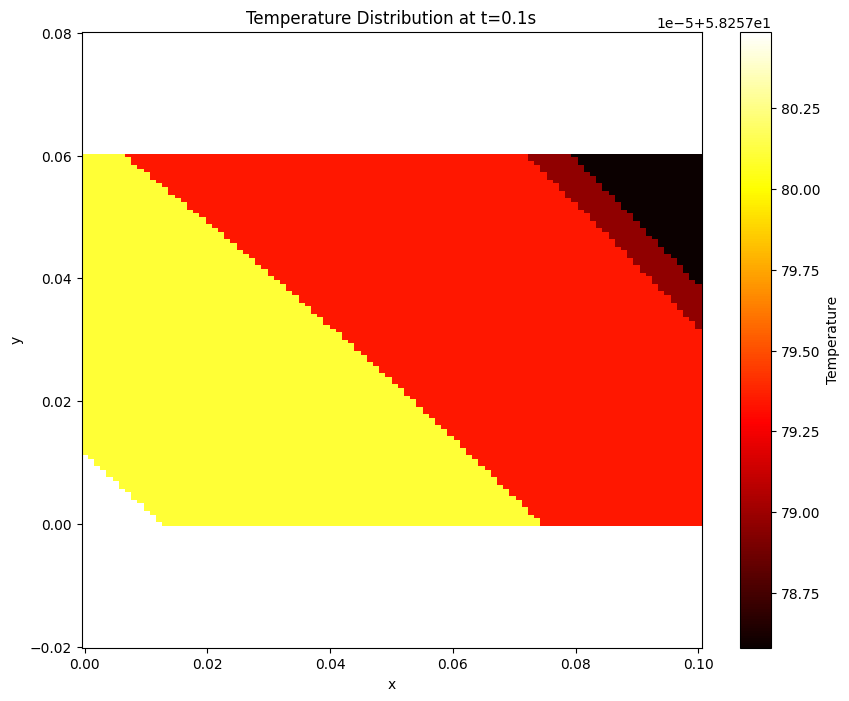

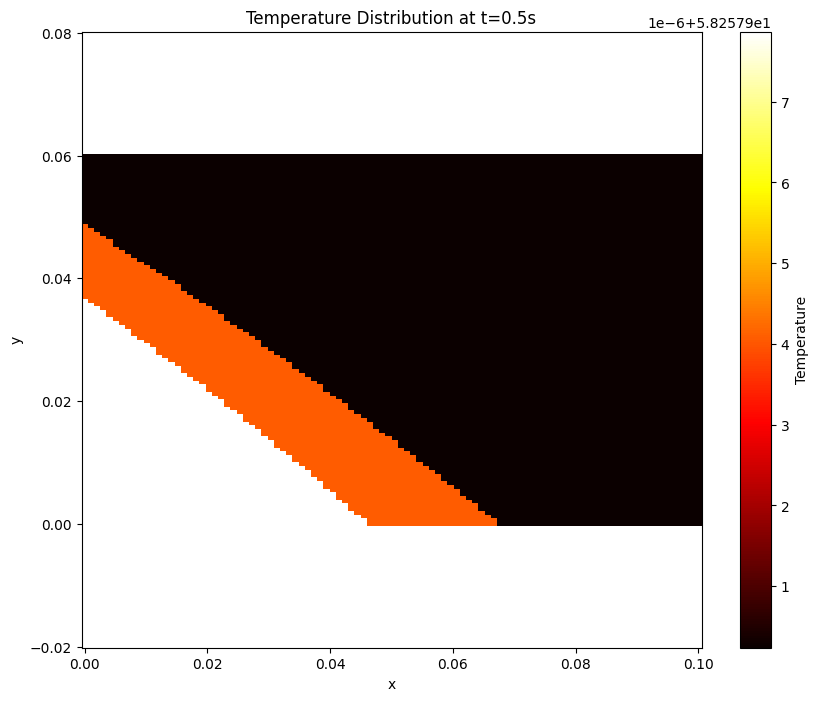

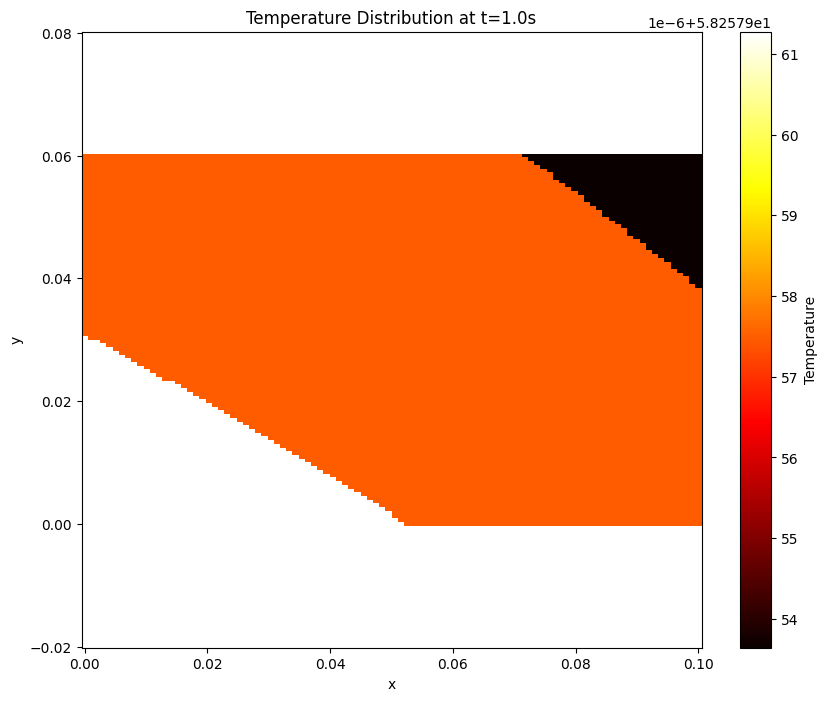

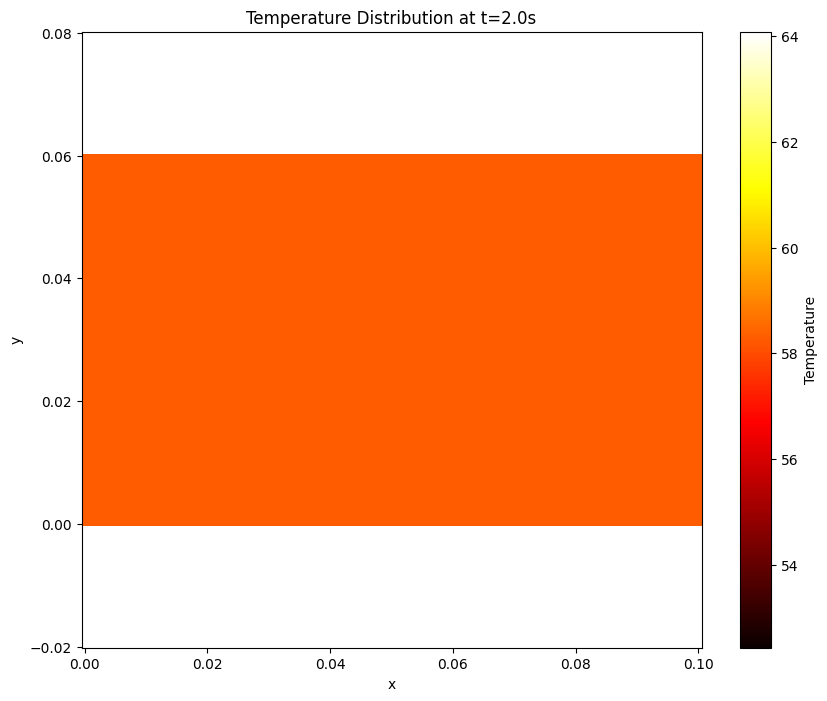

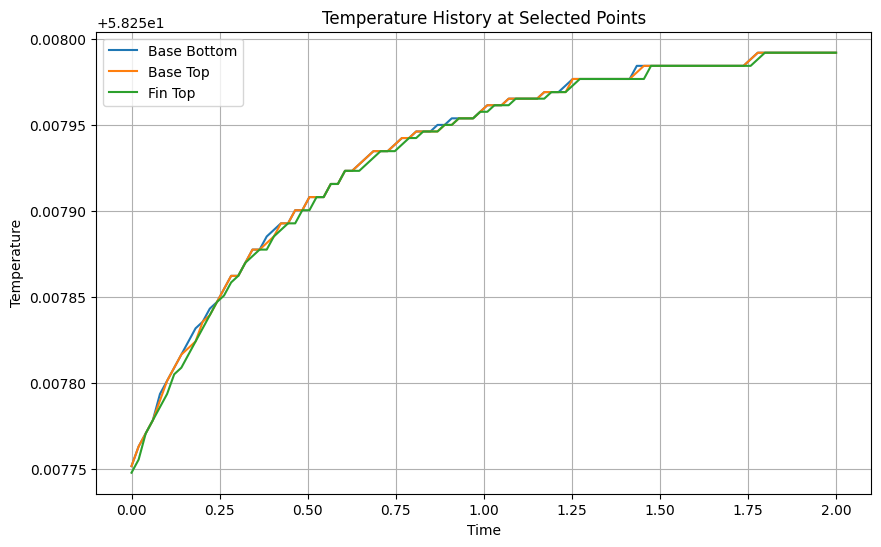

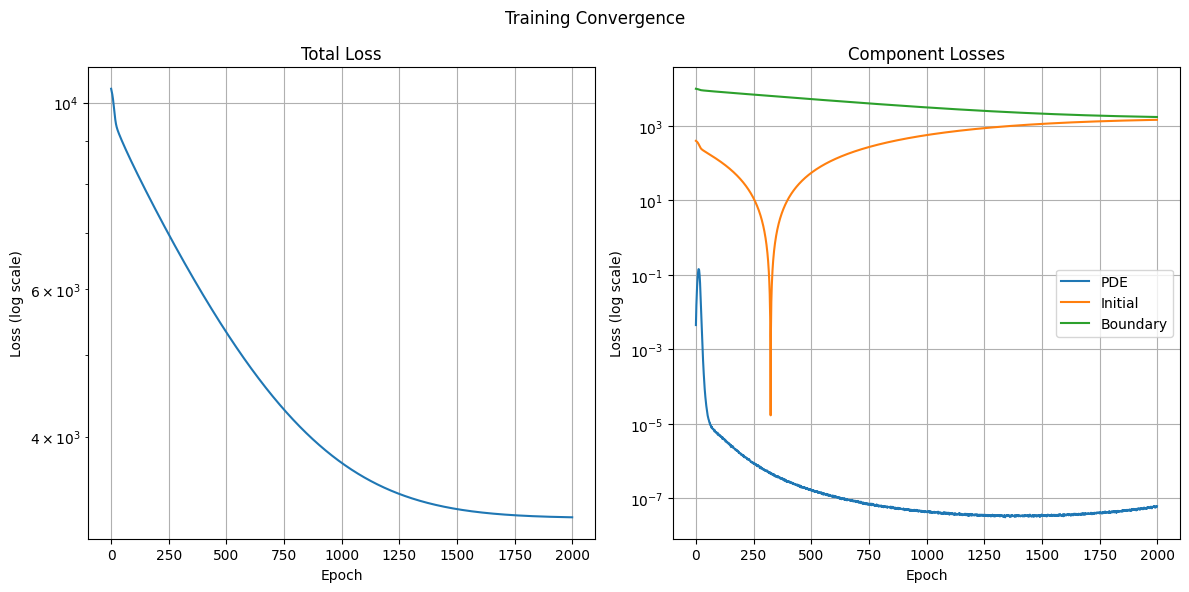

Starting heat sink optimization...
Starting Bayesian optimization...
Iteration No: 1 started. Evaluating function at random point.
Epoch 0/500 - Loss: 1.0448e+04 - Time: 0.07s
  PDE: 6.7088e-05, IC: 4.0800e+02, BC: 1.0040e+04
  Learning rate: 1.00e-03


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100/500 - Loss: 8.4002e+03 - Time: 7.34s
  PDE: 6.8010e-06, IC: 1.2084e+02, BC: 8.2794e+03
  Learning rate: 1.00e-03
Epoch 200/500 - Loss: 7.4104e+03 - Time: 13.32s
  PDE: 2.0667e-06, IC: 3.4612e+01, BC: 7.3758e+03
  Learning rate: 1.00e-03
Epoch 300/500 - Loss: 6.5909e+03 - Time: 20.51s
  PDE: 8.3535e-07, IC: 1.3844e+00, BC: 6.5896e+03
  Learning rate: 1.00e-03
Epoch 400/500 - Loss: 5.9053e+03 - Time: 26.52s
  PDE: 4.2891e-07, IC: 1.0374e+01, BC: 5.8950e+03
  Learning rate: 1.00e-03
Epoch 499/500 - Loss: 5.3393e+03 - Time: 33.48s
  PDE: 2.4640e-07, IC: 5.3203e+01, BC: 5.2861e+03
  Learning rate: 1.00e-03
Parameters: {'fin_width': 0.005981309331781195, 'fin_height': 0.04862434543907994, 'num_fins': np.int64(6)}, Objective: 0.149278
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 33.4908
Function value obtained: 0.1493
Current minimum: 0.1493
Iteration No: 2 started. Evaluating function at random point.
Epoch 0/500 - Loss: 1.0394e+04 - Time: 0.10s
  PDE: 7.8869

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100/500 - Loss: 8.5497e+03 - Time: 6.20s
  PDE: 1.0991e-06, IC: 1.3734e+02, BC: 8.4123e+03
  Learning rate: 1.00e-03
Epoch 200/500 - Loss: 7.5463e+03 - Time: 13.62s
  PDE: 2.8394e-07, IC: 4.3789e+01, BC: 7.5025e+03
  Learning rate: 1.00e-03
Epoch 300/500 - Loss: 6.7126e+03 - Time: 19.78s
  PDE: 1.1640e-07, IC: 3.6423e+00, BC: 6.7090e+03
  Learning rate: 1.00e-03
Epoch 400/500 - Loss: 6.0129e+03 - Time: 27.16s
  PDE: 5.4060e-08, IC: 6.2363e+00, BC: 6.0067e+03
  Learning rate: 1.00e-03
Epoch 499/500 - Loss: 5.4333e+03 - Time: 33.22s
  PDE: 3.3064e-08, IC: 4.3343e+01, BC: 5.3900e+03
  Learning rate: 1.00e-03
Parameters: {'fin_width': 0.002, 'fin_height': 0.02698520585810766, 'num_fins': np.int64(7)}, Objective: 0.078283
Iteration No: 16 ended. Search finished for the next optimal point.
Time taken: 33.5581
Function value obtained: 0.0783
Current minimum: 0.0783
Iteration No: 17 started. Searching for the next optimal point.
Epoch 0/500 - Loss: 1.0434e+04 - Time: 0.06s
  PDE: 2.6556e

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100/500 - Loss: 8.5678e+03 - Time: 7.12s
  PDE: 1.5272e-06, IC: 1.3940e+02, BC: 8.4284e+03
  Learning rate: 1.00e-03
Epoch 200/500 - Loss: 7.5682e+03 - Time: 12.87s
  PDE: 4.8280e-07, IC: 4.5359e+01, BC: 7.5229e+03
  Learning rate: 1.00e-03
Epoch 300/500 - Loss: 6.7346e+03 - Time: 20.00s
  PDE: 2.0950e-07, IC: 4.1599e+00, BC: 6.7305e+03
  Learning rate: 1.00e-03
Epoch 400/500 - Loss: 6.0336e+03 - Time: 25.92s
  PDE: 1.0211e-07, IC: 5.5654e+00, BC: 6.0281e+03
  Learning rate: 1.00e-03
Epoch 499/500 - Loss: 5.4522e+03 - Time: 33.01s
  PDE: 5.6493e-08, IC: 4.1501e+01, BC: 5.4107e+03
  Learning rate: 1.00e-03
Parameters: {'fin_width': 0.007513234232614607, 'fin_height': 0.02, 'num_fins': np.int64(3)}, Objective: 0.080280
Iteration No: 17 ended. Search finished for the next optimal point.
Time taken: 33.3224
Function value obtained: 0.0803
Current minimum: 0.0783
Iteration No: 18 started. Searching for the next optimal point.
Epoch 0/500 - Loss: 1.0434e+04 - Time: 0.07s
  PDE: 2.0476e

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100/500 - Loss: 8.3212e+03 - Time: 5.86s
  PDE: 2.2310e-06, IC: 1.1242e+02, BC: 8.2087e+03
  Learning rate: 1.00e-03
Epoch 200/500 - Loss: 7.3449e+03 - Time: 12.99s
  PDE: 7.2695e-07, IC: 3.0518e+01, BC: 7.3143e+03
  Learning rate: 1.00e-03
Epoch 300/500 - Loss: 6.5351e+03 - Time: 18.81s
  PDE: 2.8159e-07, IC: 6.9829e-01, BC: 6.5344e+03
  Learning rate: 1.00e-03
Epoch 400/500 - Loss: 5.8575e+03 - Time: 25.50s
  PDE: 1.4022e-07, IC: 1.2585e+01, BC: 5.8449e+03
  Learning rate: 1.00e-03
Epoch 499/500 - Loss: 5.2985e+03 - Time: 31.65s
  PDE: 8.5168e-08, IC: 5.7876e+01, BC: 5.2406e+03
  Learning rate: 1.00e-03
Parameters: {'fin_width': 0.002, 'fin_height': 0.02, 'num_fins': np.int64(3)}, Objective: 0.076475
Iteration No: 18 ended. Search finished for the next optimal point.
Time taken: 31.9274
Function value obtained: 0.0765
Current minimum: 0.0765
Optimization complete!
Optimal parameters: {'fin_width': 0.002, 'fin_height': 0.02, 'num_fins': np.int64(3)}
Optimal objective value: 0.07

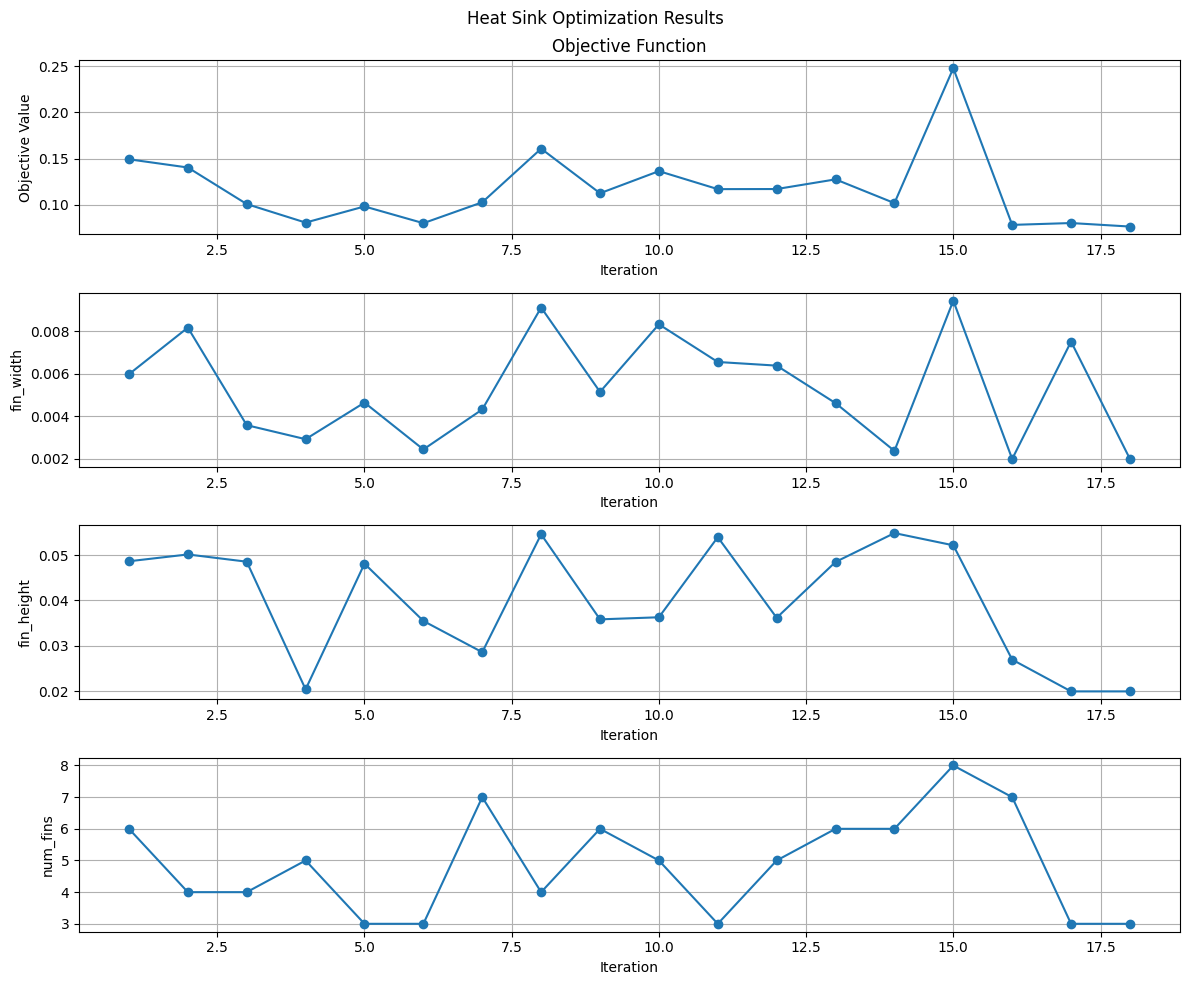

Training final model with optimal parameters...
Epoch 0/2000 - Loss: 1.0406e+04 - Time: 0.12s
  PDE: 8.3719e-05, IC: 4.0087e+02, BC: 1.0006e+04
  Learning rate: 1.00e-03


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100/2000 - Loss: 8.4864e+03 - Time: 11.91s
  PDE: 2.9254e-06, IC: 1.3025e+02, BC: 8.3561e+03
  Learning rate: 1.00e-03
Epoch 200/2000 - Loss: 7.4914e+03 - Time: 23.78s
  PDE: 9.3101e-07, IC: 3.9973e+01, BC: 7.4515e+03
  Learning rate: 1.00e-03
Epoch 300/2000 - Loss: 6.6647e+03 - Time: 35.59s
  PDE: 3.5309e-07, IC: 2.6294e+00, BC: 6.6620e+03
  Learning rate: 1.00e-03
Epoch 400/2000 - Loss: 5.9711e+03 - Time: 46.72s
  PDE: 1.7521e-07, IC: 7.7095e+00, BC: 5.9634e+03
  Learning rate: 1.00e-03
Epoch 500/2000 - Loss: 5.3919e+03 - Time: 58.07s
  PDE: 1.0089e-07, IC: 4.7537e+01, BC: 5.3444e+03
  Learning rate: 1.00e-03
Epoch 600/2000 - Loss: 4.9122e+03 - Time: 69.93s
  PDE: 6.2710e-08, IC: 1.1536e+02, BC: 4.7969e+03
  Learning rate: 1.00e-03
Epoch 700/2000 - Loss: 4.5193e+03 - Time: 81.82s
  PDE: 4.9670e-08, IC: 2.0496e+02, BC: 4.3143e+03
  Learning rate: 1.00e-03
Epoch 800/2000 - Loss: 4.2014e+03 - Time: 93.74s
  PDE: 3.7596e-08, IC: 3.1060e+02, BC: 3.8908e+03
  Learning rate: 1.00e-03


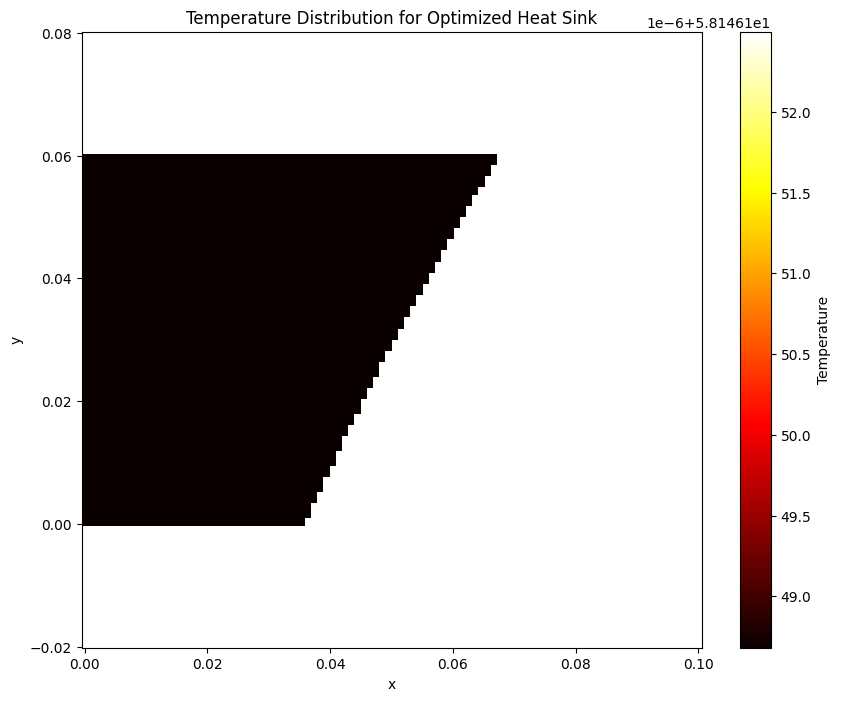

Setting up custom geometry example...
Training the model...
Epoch 0/2000 - Loss: 1.4202e+00 - Time: 0.13s
  PDE: 1.4129e+00, IC: 1.3635e-03, BC: 5.9407e-03
  Learning rate: 1.00e-03
Epoch 100/2000 - Loss: 9.6708e-01 - Time: 13.54s
  PDE: 9.5050e-01, IC: 3.2990e-03, BC: 1.3280e-02
  Learning rate: 1.00e-03
Epoch 200/2000 - Loss: 1.1191e+00 - Time: 26.99s
  PDE: 1.1156e+00, IC: 2.1800e-03, BC: 1.4071e-03
  Learning rate: 1.00e-03
Epoch 300/2000 - Loss: 8.0712e-01 - Time: 40.14s
  PDE: 7.9842e-01, IC: 2.3845e-03, BC: 6.3182e-03
  Learning rate: 1.00e-03
Epoch 400/2000 - Loss: 4.3112e-01 - Time: 53.30s
  PDE: 4.2520e-01, IC: 2.0799e-03, BC: 3.8375e-03
  Learning rate: 1.00e-03
Epoch 500/2000 - Loss: 3.1288e-01 - Time: 66.46s
  PDE: 3.0904e-01, IC: 9.8537e-04, BC: 2.8568e-03
  Learning rate: 1.00e-03
Epoch 600/2000 - Loss: 3.4532e-01 - Time: 79.75s
  PDE: 3.4212e-01, IC: 6.9090e-04, BC: 2.5075e-03
  Learning rate: 1.00e-03
Epoch 700/2000 - Loss: 3.1622e-01 - Time: 92.93s
  PDE: 3.1292e-01, 

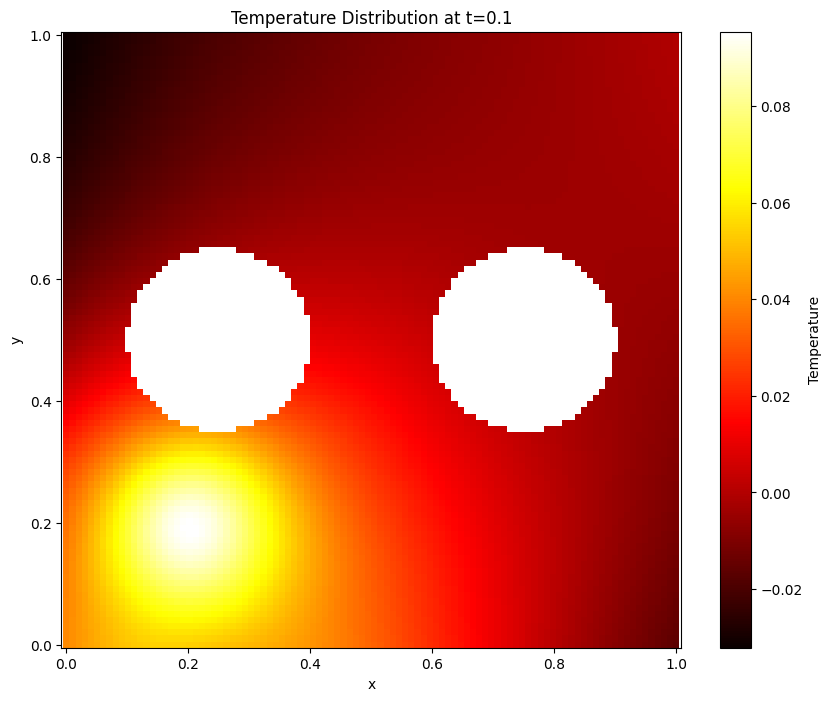

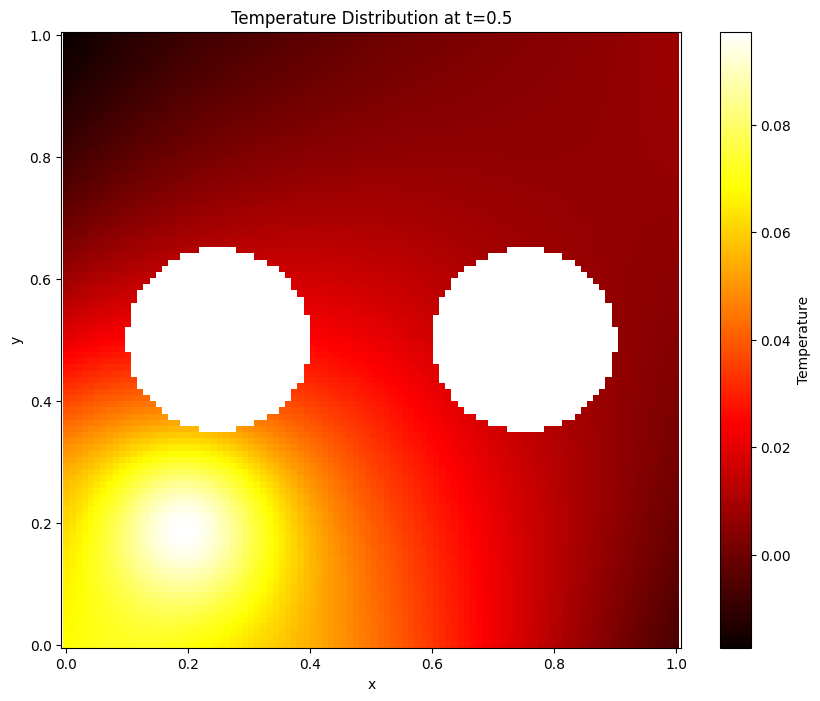

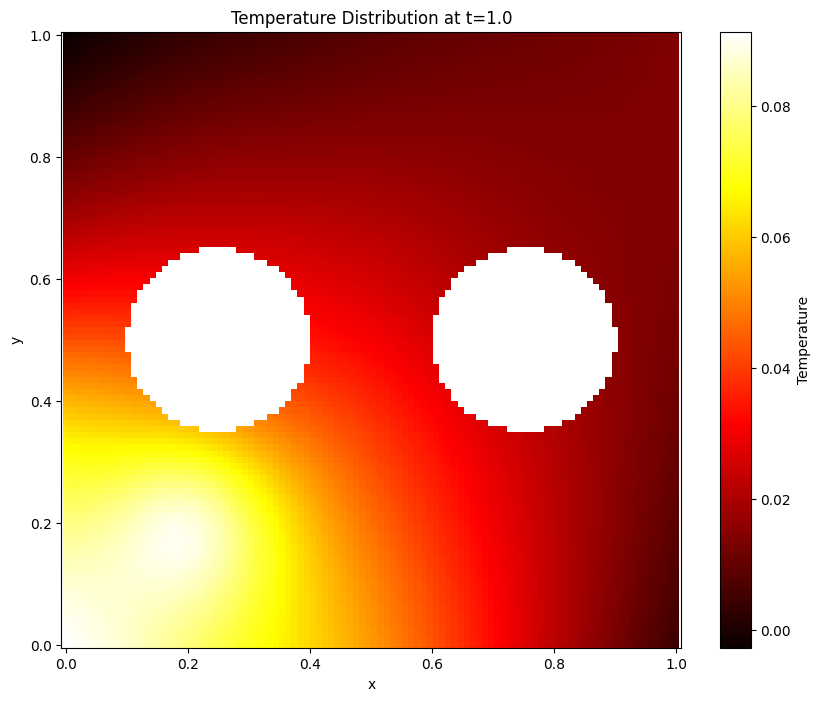

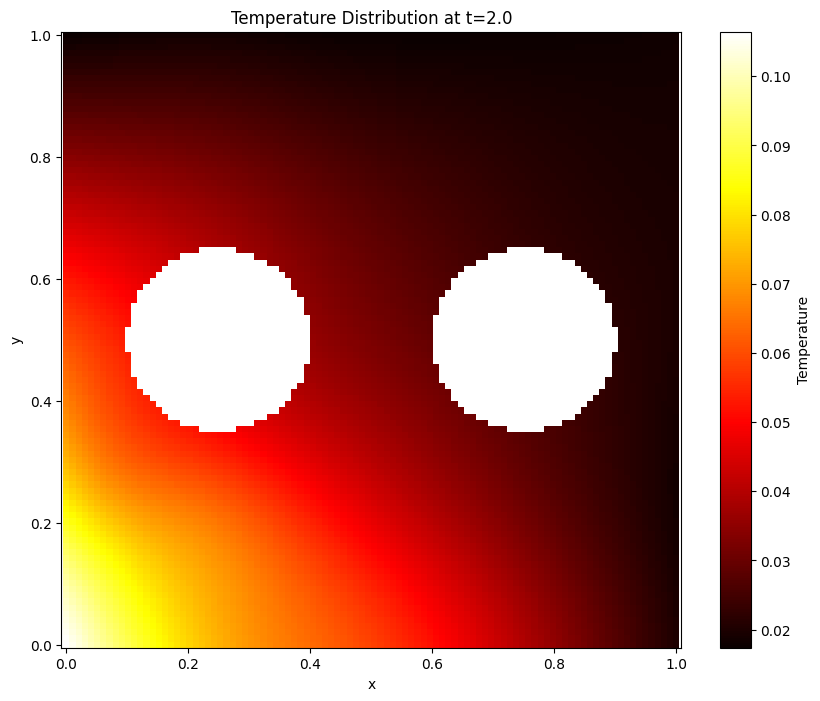

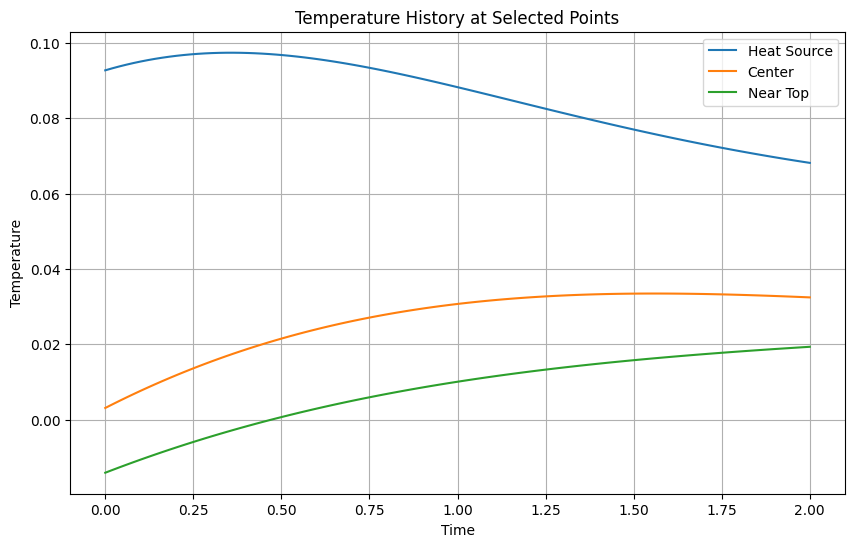

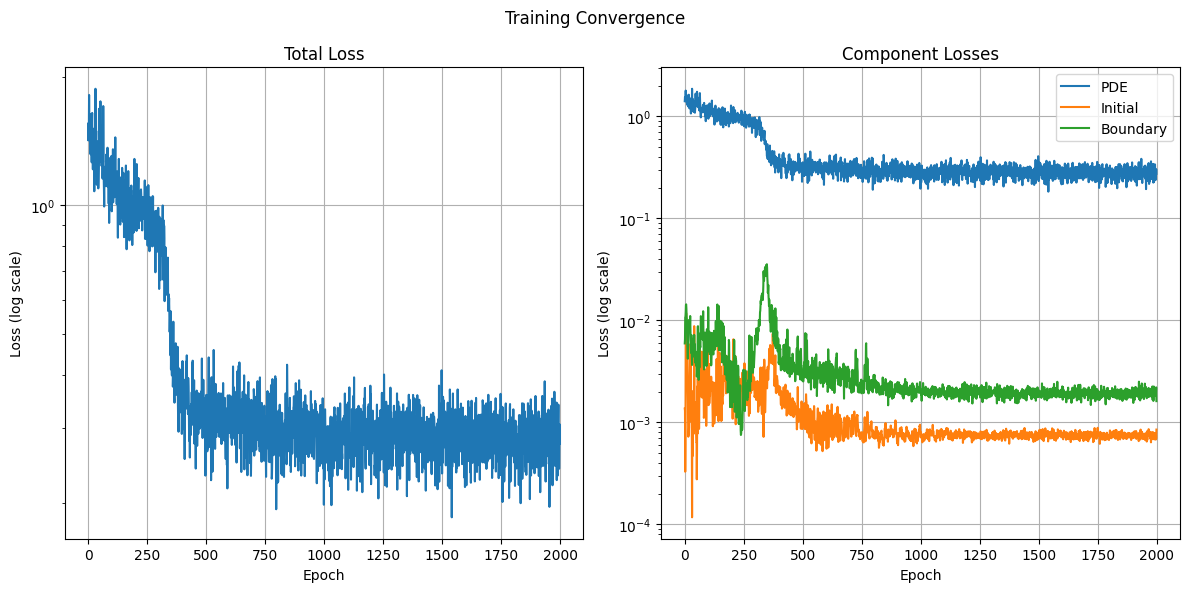

In [ ]:
project()